# Lecture 4: Decoding information in language models

In this lecture, we will introduce the basics of **probing** and **steering**: ways to **decode** their activations of neural networks and manipulate them to **control** their behavior.

### ✍ Learning goals

By the end of the lesson, we hope you feel familiar with the following concepts.

* **Linear probing**: decoding neural activations with linear transformations.
* **Relationship between probing & steering**: how we turn our ability to **predict** into a way to **control** behavior (and why it doesn't always work!).
* **Difference-in-means steering**: simple but effective method for controlling model behavior through its activations.

## 0️⃣ Setup

Run this code to get started!

In [1]:
from IPython.display import clear_output
import plotly.io as pio

try:
    import google.colab
    is_colab = True
except ImportError:
    is_colab = False

if is_colab:
    pio.renderers.default = "colab"
    !git clone https://github.com/cs221m/cs221m-course.git
    %cd cs221m-course
    !pip install -r requirements/04_probes.txt
else:
    pio.renderers.default = "plotly_mimetype+png"
    !plotly_get_chrome -y

clear_output()

For this lecture, we'll focus on a ~2B base model created by the 🤗 Transformers team. This model is small enough for us to run it on GPU, and large enough to have some interesting internal structure!

In [ ]:
from nnsight import LanguageModel

model = LanguageModel("HuggingFaceTB/SmolLM2-1.7B")

model.to("cuda")

# (demo prompt to load the model)
with model.generate("Once upon a", max_new_tokens=10):
    outputs = model.generator.output.save()

clear_output() # suppress download info

print(model.tokenizer.decode(outputs[0]))

Once upon a time, there was a little girl named Lily who


## 1️⃣ Decoding information by probing activations

### What do probes do?

Let's take our very first step towards understanding a model through its internals!

<img src="https://raw.githubusercontent.com/cs221m/cs221m-course/refs/heads/main/figures/lecture_04_probes/probing_intro.png" width="1200" alt="probing as a magnifying glass"/>

Do the intermediate activations of neural network represent high-level concepts? How can we tell? In this section, we'll look at a range of methods for **decoding information** from the hidden activations of models, often termed **probing**.

We can think of probing as something like fMRI analysis, or, alternatively, tuning a microscope lens to look into the fuzzy internals of language models. It's hard to tell what's going on by just looking at the lists of numbers outputted by each layer; but perhaps through the right transformation, we might recognize structure and concepts that we can make sense of.

<img src="https://raw.githubusercontent.com/cs221m/cs221m-course/refs/heads/main/figures/lecture_04_probes/probing_motivation.png" width="600" alt="probing, relace magnifying glass with linear layer"/>

We'll take a look at three related probing methods. All of them use a linear transformation of the model's internal state to identify and decode information in its internal processes.

* **Logit lens**: "skip ahead" and decode each layer's output into token space, as if it was the last layer.
* **PCA**: although not strictly an interpretability method, finding linear dimensions that explain the variance of high-dimensional data is a useful way of visualizing neural activations.
* **Supervised probes**: we can train linear transformations to directly decode interesting information from the model's internal states.

### Logit lens

How do we find the right "microscope lens" through which to look into the model? One natural way to do this is to re-use the model's own components.

One popular method, logit lens, does exactly that. The idea is that to understand what's stored at an intermediate layer, we can "skip ahead" and see what the model would've predicted had this been the last layer.

<img src="https://raw.githubusercontent.com/cs221m/cs221m-course/refs/heads/main/figures/lecture_04_probes/logit_lens.png" width="600" alt="logit lens"/>

We can think of the final unembedding layer of the model as a sort of probe, or lens through which to look at our activations. The unembedding layer takes in "jumbled" numeric input (a vector from the final layer of the model) and returns a probability distribution over tokens that we can read and understand!

In this section, we'll walk through logit lens step-by-step, looking at what happens under the hood when models translate sentences between different languages.

To start with, let's prompt the model to translate "amor" ("love") from Spanish to French. We'll also grab the output of the final layer along the way.

In [7]:
# prompt model to translate from Spanish to French
with model.generate("ES: amor, FR:"):
  # save last layer
  last_layer_last_token = model.model.layers[-1].output[0, -1].save()
  output = model.generator.output.save()

clear_output() # ignore comments for model loading

print(model.tokenizer.decode(output))

['ES: amor, FR: amour, G: Liebe, IT: amore, RU: люб']


We can see that the model correctly translated "amor" to "amour" - and also kept going on with languages of its own choice! This is likely because we set the model up to fill in the pattern of language: translation in our prompt.

Let's take a look at the last layer's activation over the last token:

In [8]:
print("Last layer shape:", last_layer_last_token.shape)
print("Last layer first 10 entries:", last_layer_last_token[:10].tolist())

Last layer shape: torch.Size([2048])
Last layer first 10 entries: [78.0, -15.1875, -5.0, 46.0, -32.75, -57.5, -49.0, 2.921875, -19.0, 8.875]


By itself, it's hard to make sense of this layer's activation. But one thing we do know is that this layer's activation becomes the input to the model's final unembedding layer, which converts this layer's activation into a probability distribtuion over the final token. Let's do this process "manually", and convert the final layer's representations into predictions for the next token.

In [9]:
unembedding_layer = model.lm_head

# "unembed" the final layer to get a distribution over tokens
logits = unembedding_layer(model.model.norm(last_layer_last_token))

# predicted token = token index with highest probability
next_token_prediction = logits.argmax(dim=-1)

# decode token index into string token
next_token = model.tokenizer.decode(next_token_prediction)
print("Next token:", next_token)

Next token:  am


We can see that the next token predicted by the model is "am" (first part of "amour"). This isn't too surprising, since we already knew that that's what the model outputs. What's interesting, though, is that we can re-apply the same unembedding layer at **every layer** across **every token**. 

In fact, the unembedding layer is a sort of probe! It takes in hard-to-read vector activations and returns the tokens that this activation is closest to. Although it's not guaranteed that the layer indeed promotes these tokens (after all, the model keeps processing before churning out a final output), it's one sort of lens through which we can inspect model activations and decode interesting structure.

Let's go ahead and apply our "logit lens" (i.e., the unembedding layer) to the activation over each token and each layer in our translation prompt. This time, we'll keep track of both the most likely token and its respective probability. What we'll end up is with a map - for each token, and each layer, we'll read off the token decoded by the unembedding component at that activation.

Already, we can see some surprising structure in our model!

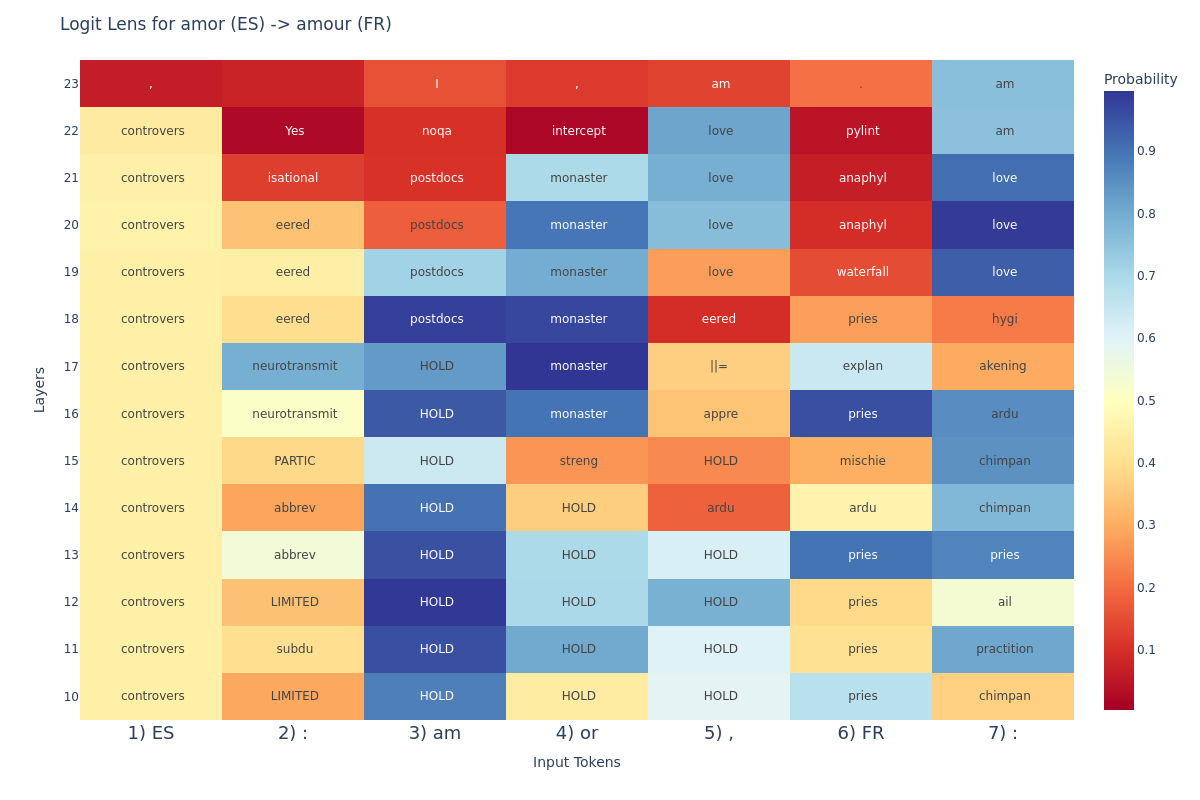

In [10]:
import torch
import plotly.express as px

prompt= "ES: amor, FR:"

# start a middle layer to save space
layer_range = list(range(10, len(model.model.layers)))

decoded_layers = []
with model.trace(prompt):
    for layer_index in layer_range:
        # get layer activation
        layer_activation = model.model.layers[layer_index].output
        layer_activation = model.model.norm(layer_activation)
        # pass the layer through the final unembedding layer to predict next token
        decoded_layer_logits = unembedding_layer(layer_activation)
        # apply softmax to get a probability distribution over the next token
        decoded_layer = torch.nn.functional.softmax(decoded_layer_logits, dim=-1)
        decoded_layers.append(decoded_layer.save())

decoded_layers = torch.cat(decoded_layers) # (num_layers, num_tokens, vocab_size)

# find the maximum probability and corresponding tokens for each position
probabilities, decoded_tokens = decoded_layers.max(dim=-1)

# decode token ids
decoded_tokens = [
    [model.tokenizer.decode(t.item()) for t in layer_tokens]
    for layer_tokens in decoded_tokens
]

input_tokens = [t.replace('Ġ', '') for t in model.tokenizer.tokenize(prompt)]

# plot as a map over tokens & indices
fig = px.imshow(
    probabilities.detach().cpu().float().numpy(),
    x=[f"{i+1}) {t}" for i, t in enumerate(input_tokens)],
    y=layer_range,
    origin="lower", # make 0 at the bottom
    color_continuous_scale=px.colors.diverging.RdYlBu,
    color_continuous_midpoint=0.50,
    text_auto=True,
    labels=dict(x="Input Tokens", y="Layers", color="Probability")
)

# prettify
fig.update_layout(
    title='Logit Lens for amor (ES) -> amour (FR)',
    xaxis_tickangle=0,
    width=1200,
    height=800
)

fig.update_xaxes(tickfont_size=18) 
fig.update_yaxes(tickvals=layer_range)
fig.update_traces(text=decoded_tokens, texttemplate="%{text}")

fig.show()

Let's read the plot. We structured it to reflect how we've been visualizing the way our model processes information: the input is on the bottom, and the model works left to right & bottom to top. The model's final prediction, "am", is at the top right (final layer, final token). For each cell, we see the decoded token using the unembedding layer on that activation.

Many of the decoded activations are hard to understand, and don't seem to have a clear connection with the model's final prediction at that token position. This might be what we expect - the model's internal structure is dynamic and complex, and it's not a guarantee that the same component that decodes its final layer would also meaningfully decode intermediate computations.

Nevertheless, focusing on the final ":" token, we see something rather surprising in the middle-to-late layers. Right before predicting "am", the model's intermediate activations get decoded to "love". But we never asked the model to translate into English! Does this mean that, when translating from Spanish to French, our language model is thinking in English?

### ✏ **Exercise 1**

Either by using the code above or by using the [nnsight workbench](https://workbench-git-v2-ndif.vercel.app/), try logit lens with a few more prompts (translating different languages, factual recall, simple math).

Do you notice any interesting patterns?

In [32]:
# (optionally) your code here

Why do you think intermediate layers get decoded into English for a translation task that doesn't involve English? Is this strong evidence that the model "thinks in English"? If not, how would you go about testing whether a language model does?

> FILL IN YOUR ANSWER HERE

### PCA and visualizing activations


Logit lens is a useful way of getting a glimpse into how information might flow within the model as it processes its input. However, it makes a fairly strict assumption about the structure of these activations; it's not a guarantee that the way information is structured in the middle layers matches the way it's decoded into tokens in the very final layer.

If we want to visualize our activations without making this assumption, we can draw on more traditional machine learning tools for working with high-dimensional data. Here, we'll take a quick look at how principal component analysis (PCA) can help us identify key linear dimensions along which to visualize our data.

<img src="https://raw.githubusercontent.com/cs221m/cs221m-course/refs/heads/main/figures/lecture_04_probes/pca_cropped.gif" width="600" alt="logit lens"/>

PCA is a method for finding the linear dimensions (principcal components) that capture the most variance in the data. In traditional machine learning, PCA components identify combinations of feature that explain a large dataset. For our purposes, PCA is a lightweight unsupervised method for reducing the dimensionality of hidden representations so that we can visualize them.

The animation above illustrates how a single PCA component reduces 2-dimensional data into a single dimension, while preserving the variance in the data (e.g., the distinction between the top and bottom clusters). After projecting every datapoint onto the PCA 1 line, we get a 1-dimensional representation of the same data. More generally, PCA reduces $n$-dimesional data into $k \ll n$ dimensinos by projecting the data onto the top $k$ principal components that explain the variance in the data.

Let's collect activations for a small hand-constructed translation dataset, and project the $2048$-dimension vectors onto a 2-dimensional space that we can more easily visualize.

In [11]:
# task: translating from the same English word to either French or Spanish
ENGLISH_TO_FRENCH = [
    "English: dog, Francais:",
    "English: cat, Francais:",
    "English: mouse, Francais:",
    "English: fish, Francais:",
    "English: bird, Francais:",
    "English: turtle, Francais:",
    "English: monkey, Francais:",
    "English: bear, Francais:",
    "English: lion, Francais:",
    "English: penguin, Francais:"
]

ENGLISH_TO_SPANISH = [
    "English: dog, Espanol:",
    "English: cat, Espanol:",
    "English: mouse, Espanol:",
    "English: fish, Espanol:",
    "English: bird, Espanol:",
    "English: turtle, Espanol:",
    "English: monkey, Espanol:",
    "English: bear, Espanol:",
    "English: lion, Espanol:",
    "English: penguin, Espanol:"
]

In [12]:
# let's collect the model's activations over each statement at the same location
from tqdm import tqdm
import torch

LAYER = 10 # pick a middle layer

with torch.no_grad():
  french_activations = []
  for french_prompt in tqdm(ENGLISH_TO_FRENCH, desc="French"):
    with model.trace(french_prompt):
      # get activation at layer L & last token (:)
      french_activations.append(
          model.model.layers[LAYER].output[:, -1, :].save()
      )

  # repeat for english-to-spanish prompts
  spanish_activations = []
  for spanish_prompt in tqdm(ENGLISH_TO_SPANISH, desc="Spanish"):
    with model.trace(spanish_prompt):
      spanish_activations.append(
          model.model.layers[LAYER].output[:, -1, :].save()
      )

# convert to tensors
french_activations = torch.cat(french_activations) # (10, hidden_dim)
spanish_activations = torch.cat(spanish_activations) # (10, hidden_dim)

Spanish: 100%|██████████| 10/10 [00:06<00:00,  1.47it/s]


By transforming the activations with PCA, we reduce the dimension from $2048 \to 2$, projecting the activations onto the 2 dimensions that capture the most variance between activations in our small dataset.

In [13]:
# go from hidden size -> 2 dimensions with PCA!
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
all_activations = torch.cat([french_activations, spanish_activations]).cpu().float().numpy() # (20, hidden_dim)

low_dim_activations = pca.fit_transform(all_activations) # (20, 2)

print("Shape before PCA:", all_activations.shape) # (20, hidden_dim)
print("Shape after PCA:", low_dim_activations.shape) # (20, 2)

Shape before PCA: (20, 2048)
Shape after PCA: (20, 2)


Now, we can plot the activations along these PCA dimensions. Much easier than plotting the activations across 2048 dimensions!

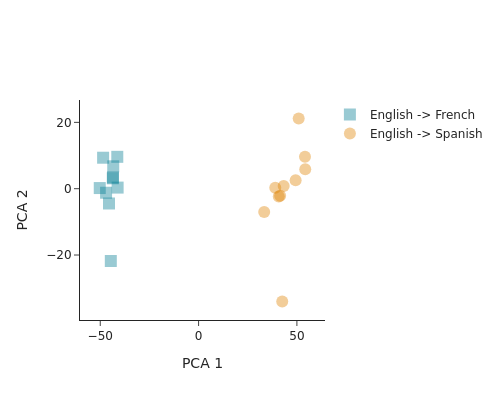

In [19]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
  x=low_dim_activations[:10, 0],
  y=low_dim_activations[:10, 1],
  mode='markers',
  marker=dict(symbol='square', color="rgba(0, 124, 146, 0.4)", size=12),
  name='English -> French',
  hovertext=ENGLISH_TO_FRENCH,
))

fig.add_trace(go.Scatter(
  x=low_dim_activations[10:, 0],
  y=low_dim_activations[10:, 1],
  mode='markers',
  marker=dict(symbol='circle', color="rgba(223, 131, 0, 0.4)", size=12),
  name='English -> Spanish',
  hovertext=ENGLISH_TO_SPANISH,
))

fig.update_layout(
  template='simple_white',
  width=500,
  height=400,
  xaxis_title='PCA 1',
  yaxis_title='PCA 2',
)

fig.show()

We can see that, projected down to two dimensions, the activations over the final ":" token form two distinct clusters for the English-to-French and English-to-Spanish prompts. PCA 1 is already enough to separate the two clusters. The model's activations over these prompts at layer 10 are linearly separable.

### ✏ **Exercise 2**

An important thing to note is that the PCA dimensions we identified are constrained to the dataset of animals we procured.

For instance, PCA 1 seems to clearly separate between English-to-French translation prompts and English-to-Spanish translation prompts. Anything below 0 on the PCA 1 axis is English-to-French, and anything about 0 is English-to-Spanish.

But what if we go beyond animals? Does our analysis hold for other translations?

Come up with an English-to-Spanish prompt that our PCA analysis would incorrectly categorize as French. How do you know?

*Hint: What if we tried words that don't need translating?*

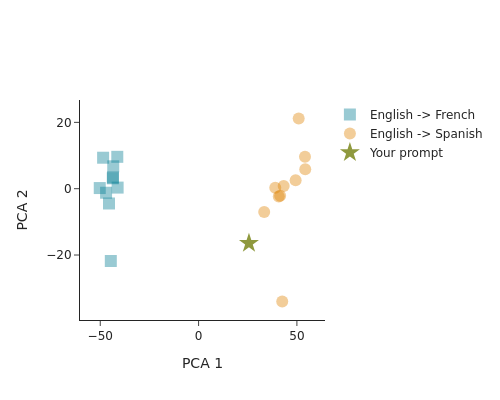

In [20]:
YOUR_PROMPT = "English: love, Espanol:" # change the input!

with torch.no_grad():
  with model.trace(YOUR_PROMPT):
    # get activation at layer L & last token (:)
    activation = model.model.layers[LAYER].output[:, -1, :].save()

activation_low_dim = pca.transform(activation.cpu().float().numpy())

# your code here!
fig.add_trace(go.Scatter(
  x=activation_low_dim[:, 0],
  y=activation_low_dim[:, 1],
  mode='markers',
  marker=dict(symbol='star', color="#8F993E", size=15),
  name='Your prompt',
  hovertext=YOUR_PROMPT
))

fig.show()

What was the prompt you chose, and how did you come up with it?

> FILL IN YOUR ANSWER HERE

### Supervised linear probes

Let's recall the original motivation of probing: we want to decode relevant information from the model's internals.

<img src="https://raw.githubusercontent.com/cs221m/cs221m-course/refs/heads/main/figures/lecture_04_probes/probing_motivation.png" width="600" alt="probing, relace magnifying glass with linear layer"/>

We can think of logit lens and PCA as two possible instantiations of such a probe:
* **Logit lens**: pre-initialize the probe to be equal to the final unembedding layer of the model, mapping from activations to tokens.
* **PCA**: create a linear distinguisher in an unsupervised way, capturing the variance between the activations in our dataset.

But what if, instead of pre-initializing or unsupervised training, we train a probe directly to decode information from the model's activations?

In this section, we'll train a supervised probe to decode the language of the input from the model's internal activation. In the following section, we'll go into some of the possible issues from taking this approach.

In [21]:
# small dataset with statements in different languages
import pandas as pd

languages_df = pd.DataFrame([
    {
        "en": "Hello.",
        "es": "Hola.",
        "fr": "Bonjour.",
        "de": "Hallo."
    },
    {
        "en": "Good night.",
        "es": "Buenas noches.",
        "fr": "Bonne nuit.",
        "de": "Gute Nacht."
    },
    {
        "en": "How are you?",
        "es": "¿Cómo estás?",
        "fr": "Comment ça va ?",
        "de": "Wie geht's?"
    },
    {
        "en": "I am happy.",
        "es": "Estoy feliz.",
        "fr": "Je suis heureux.",
        "de": "Ich bin glücklich."
    },
    {
        "en": "See you soon.",
        "es": "Hasta pronto.",
        "fr": "À bientôt.",
        "de": "Bis bald."
    },
    {
        "en": "Thank you.",
        "es": "Gracias.",
        "fr": "Merci.",
        "de": "Danke."
    },
    {
        "en": "Yes, please.",
        "es": "Sí, por favor.",
        "fr": "Oui, s'il vous plaît.",
        "de": "Ja, bitte."
    },
    {
        "en": "No, thanks.",
        "es": "No, gracias.",
        "fr": "Non, merci.",
        "de": "Nein, danke."
    },
    {
        "en": "I love you.",
        "es": "Te quiero.",
        "fr": "Je t'aime.",
        "de": "Ich liebe dich."
    },
    {
        "en": "It is cold.",
        "es": "Hace frío.",
        "fr": "Il fait froid.",
        "de": "Es ist kalt."
    }
])

In [22]:
# collect activations at layer 20
import torch
from tqdm import trange

# this time, we'll look at a layer that's more downstream
LAYER = 20

# all activations = [en_1, es_1, fr_1, de_1, en_2, es_2, ...]
all_activations = []
with torch.no_grad():
  for i in trange(languages_df.shape[0]):
    row = languages_df.iloc[i]
    # process sentences as one batch sentence
    with model.trace(row.values.tolist()):
      all_activations.append(model.model.layers[LAYER].output[:, -1, :].save())

all_activations = torch.cat(all_activations, dim=0).cpu().float().numpy() # (40, hidden dim)

100%|██████████| 10/10 [00:18<00:00,  1.85s/it]


Let's train a linear classifier to predict the language from the input! Usually, we'd split up the dataset into training and testing, but since it's a small dataset we'll just report the training score.

In [23]:
# train 
from sklearn.linear_model import LogisticRegression

X = all_activations
y = ['en', 'es', 'fr', 'de'] * len(languages_df) # labels = [en, es, fr, de, en, es, ...]

linear_probe = LogisticRegression(random_state=12, fit_intercept=False)
linear_probe.fit(X, y)

linear_probe.score(X, y)

1.0

We get 100% training accuracy - our linear predictor can decode the language of the input from the model's internal state! Although it's quite fragile, the model does seem to somewhat generalize to sentences outside our dataset.

In [24]:
# try inputs in different languages! does our probe work consistently?
prompt = "Bon appetit"

with torch.no_grad():
  with model.trace(prompt):
    activation = model.model.layers[LAYER].output[:, -1, :].save()
input_activation = activation.cpu().float().numpy()

prediction = linear_probe.predict(input_activation)[0]
print("Prompt:", prompt)
print("Linear probe prediction:", prediction)

Prompt: Bon appetit
Linear probe prediction: fr


### ✏ **Exercise 3**

Let's return to PCA to visualize what our supervised probe might be doing. This exercise will be slightly more involved.

First, reuse the code from the PCA section to fit a PCA with 2 dimensions to our data, and project the activations onto its components with `fit_transformer`.

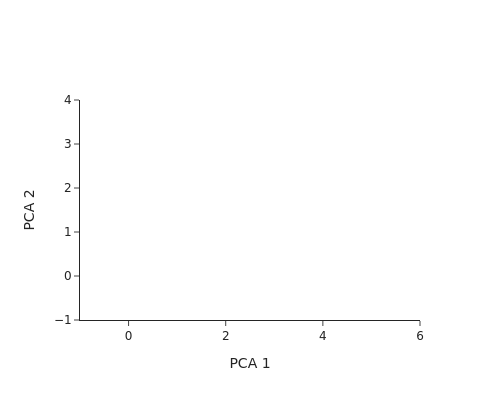

In [112]:
# visualize activations
import numpy as np
import plotly.graph_objects as go

################## YOUR CODE HERE ##################
# use this as the input to your PCA
input_to_pca = all_activations
# 1. create a PCA model with n_components = 2
pass
# 2. use fit_transform to fit the PCA to the data & transform the activations
low_dim_activations = None
################## YOUR CODE HERE ##################

colors = [
    "rgba(0, 124, 146, 0.4)", 
    "rgba(223, 131, 0, 0.4)", 
    "rgba(143, 153, 62, 0.4)",
    "rgba(127, 45, 72, 0.4)"
]

fig = go.Figure()

if low_dim_activations is not None:
    index = 0
    for language, color in zip(languages_df.columns, colors):
        fig.add_trace(go.Scatter(
            x=low_dim_activations[index::4, 0],
            y=low_dim_activations[index::4, 1],
            mode='markers',
            marker=dict(symbol='circle', color=color, size=12),
            name=language,
            hovertext=languages_df[language],
        ))
        index += 1 # loop through activations

fig.update_layout(
  template='simple_white',
  width=500,
  height=400,
  xaxis_title='PCA 1',
  yaxis_title='PCA 2',
)

fig.show()

Next, we'll plot the decision boundary for English vs. other languages. We'll do this by taking the coefficients from our linear probe and projecting them onto the PCA components. You don't need to write any code for this part.

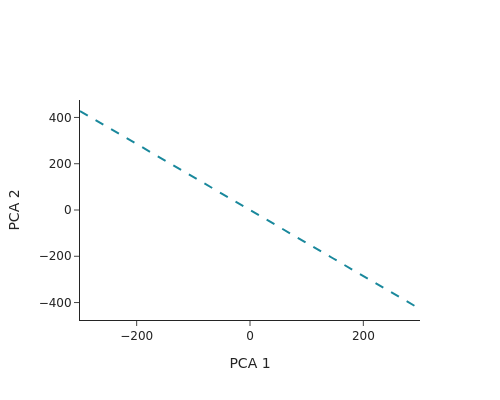

In [113]:
language_idx = list(linear_probe.classes_).index('en')
linear_weights = linear_probe.coef_[language_idx] # (2048,)

# project weight vector into PCA space
# decision = w0 * x + w1 * y 
# when decision > 0, predict English, otherwise predict "not English"
weights_pca = pca.components_ @ linear_weights # (2,) decision = w0 * x + w1 * y > 0

# plot decision boundary, which is when decision = 0
# w0 * x + w1 * y = 0
# -> y = (-w0 / w1) * x
x = np.linspace(-300, 300, 200)
y = -(weights_pca[0] / weights_pca[1]) * x

fig.add_trace(go.Scatter(
    x=x, 
    y=y,
    mode='lines',
    line=dict(color='rgba(0, 124, 146, 0.9)', width=2, dash='dash'),
    name='English boundary',
))

fig.show()

The dashed line shows the decision boundary just for English. Holding the predictions for other languages constant, the model predicts English when the activation (projected to our PCA components) is below the boundary line, and another language when the activation is above the boundary.

Lastly, play around with the model and find a sentence that our linear probe **incorrectly classifies** as English (or, conversely, find a sentence that the linear probe incorrectly classifies as not English). Follow the steps we took in Exercise 2 to:
1. Collect the activation for the sentence using `model.trace()`,
2. Pass the activation into our linear probe, and print the probe's prediction,
3. Project the activation onto our PCA with `pca.transform()`, and 
4. Plot the new PCA-projected activation on top of our existing plot as a star.

We did the first step for you. Please implement steps 2-4 yourself.

*Hint: if you're replotting different input attempts, you can refresh the plot by re-running the cells above.*

Probe prediction:  ...


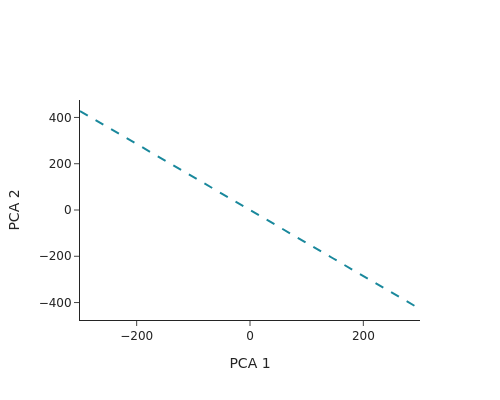

In [114]:
YOUR_PROMPT = "croissant." # change the input! to play fair, keep the "." at the end of the prompt to match our data format 

with torch.no_grad():
  with model.trace(YOUR_PROMPT):
    # get activation at layer L & last token (:)
    activation = model.model.layers[LAYER].output[:, -1, :].save()

activation = activation.cpu().float().numpy()

###################### YOUR CODE HERE ######################
# 1. use `linear_probe.predict()` and print the prediction.
pass
print("Probe prediction: ", "...")

# 2. use `pca.transform()` to transform the activation into our 2D space.
pass

# 3. add a trace to the plot that plots the projected projection as a star.
pass
############################################################

fig.show()

State the input that the linear probe misclassified as English (or as not English). Why do you think the model misclassified the sentence? Do you think the misclassification says something about how the model represents the input, or something about our probe? How would you be able to tell?

> FILL IN YOUR ANSWER HERE

### 🧠 Takeaways

In this section, we surveyed a few ways of decoding information from the modeling using linear probes. All probes try to prediction information that's understandable to us from the model's internals.
* **Logit lens**: pre-initialized probe that maps activations to token values.
* **PCA**: unsupervised probe that finds linear directions which capture variance in a collection of activations.
* **Suprvised probe**: probe that's directly trained to read values that we care about from the input (e.g., the language of the input).

How can we use our ability to decode information from the model to control the model's behavior? In the next section, we'll take a bit of a tangent that's also a bit of a deeper dive into how probes that read information help us construct causal **interventions** that change the model's behavior. Along the way, we'll also see how probes that search for correlation might not identify the right path of causation for creating interventions.

## 2️⃣ Deep dive: probes and interventions, correlation and causation

### Motivating example: Professor X

As we just saw, even in a low-dimension space, we can decode the language of the input from the model's activation! But what's driving the difference between the activations of these different languages?

Different **linear probes** can give us directions in the latent space of the LLM that separate activations of different languages. But we should be careful, because **probes are likely to pick up on correlations instead of causal directions!**

To understand why this might happen, let's consider an example story.

<img src="https://raw.githubusercontent.com/cs221m/cs221m-course/refs/heads/main/figures/lecture_04_probes/probing_vs_steering_cropped.gif" width="1200" alt="probing, relace magnifying glass with linear layer"/>

Imagine that Prof. X wants to improve the outcomes of his gifted students. Prof. X keeps track of how many assignments a student turned in and their average grade on those assignments, and wants to use this information to predict whether the student passed the final.

But **predicting** is not enough. Prof. X wants to use the information from his predictor to **improve** his students' performance on the final next year. Can his predictor give Prof. X useful information about the **intervention** he should design to improve student performance?

In [25]:
# create fake dataset of students
import numpy as np

np.random.seed(12)

N = 20

low_group_effort = np.random.normal(loc=5, scale=1.8, size=N)
high_group_effort = np.random.normal(loc=10, scale=1.8, size=N)

low_group_grade = 0.5 * low_group_effort + np.random.normal(loc=5, scale=0.3, size=N)
high_group_grade = 0.5 * high_group_effort + np.random.normal(loc=7, scale=0.3, size=N)

X = np.stack((
    np.concatenate((low_group_effort, high_group_effort)), # x-axis
    np.concatenate((low_group_grade, high_group_grade)) # y-axis
), axis=1)

X = X - X.mean(axis=0) # center

y = ['low'] * N + ['high'] * N

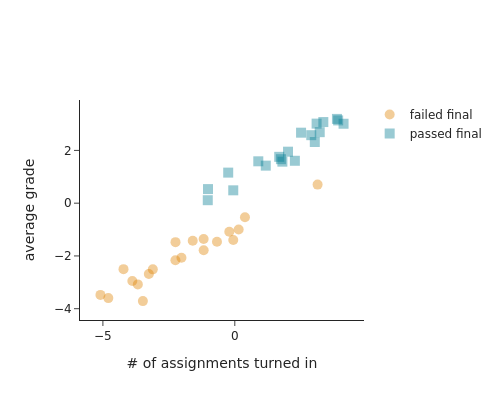

In [26]:
# plot grade by # assignments turned in
import plotly.graph_objects as go

fig = go.Figure()

fig.add_traces([
  go.Scatter(
    x=X[:N, 0],
    y=X[:N, 1],
    mode='markers',
    marker=dict(symbol='circle', color="rgba(223, 131, 0, 0.4)", size=10),
    name='failed final',
  ),
  go.Scatter(
    x=X[N:, 0],
    y=X[N:, 1],
    mode='markers',
    marker=dict(symbol='square', color="rgba(0, 124, 146, 0.4)", size=10),
    name='passed final',
  )
])

fig.update_layout(
  template='simple_white',
  width=500,
  height=400,
  xaxis_title='# of assignments turned in',
  yaxis_title='average grade',
  xaxis=dict(scaleanchor="y", scaleratio=1), # Anchor x-axis to y-axis with 1:1 ratio
  yaxis=dict(scaleanchor="x", scaleratio=1)  # Anchor y-axis to x-axis with 1:1 ratio
)

fig.show()

Looking at the data, we can see that the number of assignments turned in correlates with the average grade. Both average grade and number of assignments turned in also seem predictive of the students' performance on the final. Which feature will our probes pick out?

### Interventions from linear probes

A simple linear probe (logistic regression) will find the boundary that maximizes the margin between the students who passed and failed the final. However, it's **likely to pick up on spurious correlations that don't drive the difference between the two groups!**

In [27]:
from sklearn.linear_model import LogisticRegression

lr_probe = LogisticRegression(fit_intercept=False, random_state=12)
lr_probe.fit(X, y)

lr_probe.score(X, y)

0.975

In [28]:
theta = lr_probe.coef_[0]
theta

array([ 0.4126429 , -2.12310183])

Let's visualize the boundary drawn by our logistic regression probe. It neatly classifies between students who passed and students who failed the final!

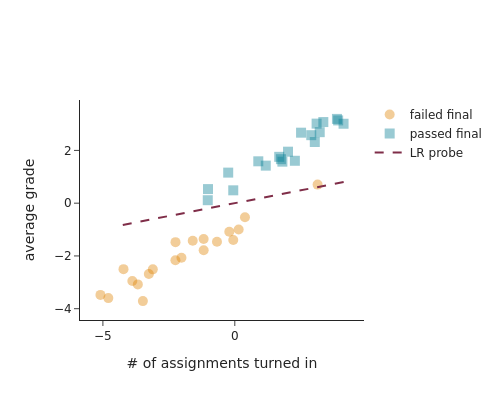

In [29]:
import plotly.graph_objects as go

# flip x & y -? flip around 45-degree line
# negate x -> flip around y-axis
theta_orthogonal = np.array([-theta[1], theta[0]])

# add trendline
t = np.linspace(-2, 2, 100)
probe_x = t * theta_orthogonal[0]
probe_y = t * theta_orthogonal[1]

fig.add_trace(
  go.Scatter(
    x=probe_x,
    y=probe_y,
    mode='lines',
    line=dict(color="#7F2D48", width=2, dash='dash'),
    name='LR probe'
  )
)

fig.show()

What would it look like to go from a **prediction** made by the probe to an **intervention** on our dataset? One way to think about this is to ask, for a given student (a dot in our plot), what would we need to change about them to change the prediction of our linear probe?

We can visualize this by drawing an arrow that's orthogonal to our prediction boundary. If we take a student that failed the final and change their values along the arrow's direction, we'll eventually cross the probe's decision boundary and get a student that will pass the final (at least, according to our predictor!).

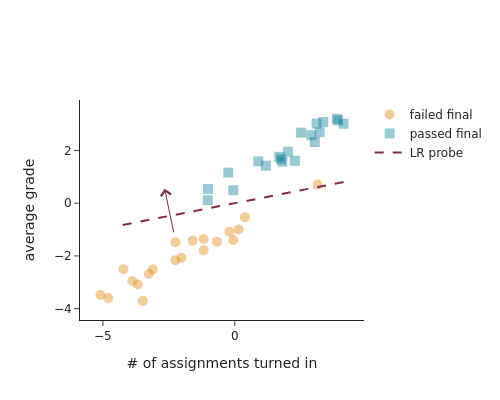

In [31]:
# what if we intervene on our data according to our probe?

# take a random student
example_student_index = 7
example_student_stats = X[example_student_index]

# intervene on our student by shifting their score according to the linear predictor!
example_student_stats_intervened = example_student_stats - theta

# draw arrow from example student to the resulting intervention
fig.add_annotation(
  ax=example_student_stats[0],  # x-coordinate of the arrow's head
  ay=example_student_stats[1] + 0.05,  # y-coordinate of the arrow's head
  x=example_student_stats_intervened[0], # x-coordinate of the arrow's tail
  y=example_student_stats_intervened[1] - 0.1, # y-coordinate of the arrow's tail
  xref='x', yref='y', # Reference coordinates to the plot's x and y axes
  axref='x', ayref='y',
  showarrow=True,
  arrowhead=4, # Style of the arrowhead (e.g., 1, 2, 3, 4, 5)
  arrowsize=2,
  arrowwidth=1,
  arrowcolor="#7F2D48",
)

fig.show()

Let's try to interpret the intervention suggested by our linear probe. Looks like our probe suggests taking the following actions: (1) increase the students' grades, and (2) have the students turn in less assignments.

Presumably, bumping everyone's grades' up won't have the intended effect of helping people pass the final... Indeed, if we draw an arrow in the direction of the linear probe, we see that it doesn't do a great job at bringing the two distributions of students close together.

In this case, the **direction** of the LR probe isn't meaningful - it tells the students apart, but doesn't help us **steer** a student who's on track to fail the class towards passing it.

Let's look at an alternative linear probe, which we haven't covered yet.

### Difference in means

A simple but effective alternative to supervised logistic regression probes is **difference in means** steering (sometimes also called "mean-mass probing" or "activation transport").

To classify between groups of students, we take the difference between the mean student who passed the final and the mean student who didn't pass. What we get is a direction vector that roughly tells the two classes apart, but more importantly tells us how to bridge between the two distribution.

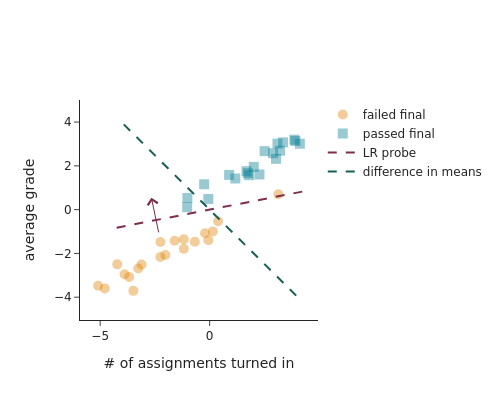

In [32]:
# compute difference in means

# take the difference between the two means
mean_low = X[:N].mean(axis=0)
mean_high = X[N:].mean(axis=0)
difference_in_means = mean_high - mean_low

# plot the decision boundary for difference-in-means vector
difference_in_means_boundary = np.array([-difference_in_means[1], difference_in_means[0]])

# add trendline
t = np.linspace(-1, 1, 100)
probe_x = t * difference_in_means_boundary[0]
probe_y = t * difference_in_means_boundary[1]

fig.add_trace(
    go.Scatter(
        x=probe_x,
        y=probe_y,
        mode='lines',
        line=dict(color="#175E54", width=2, dash='dash'),
        name='difference in means'
    )
)

fig.show()

What happens when we follow the intervention suggested by difference in means? Let's visualize the transformation for the same student, this time along the direction of the difference-in-means vector.

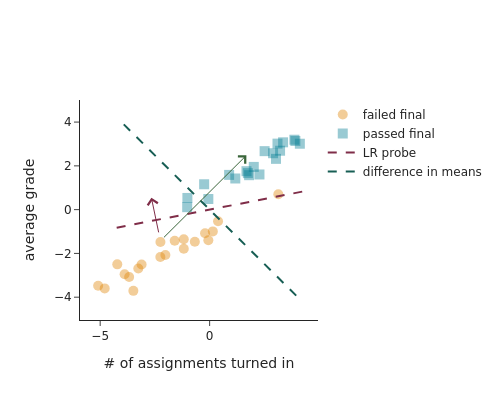

In [33]:
# apply intervention to the same exapmle student
example_student_diff_in_means = example_student_stats + difference_in_means

fig.add_annotation(
    ax=example_student_stats[0],  # x-coordinate of the arrow's head
    ay=example_student_stats[1] + 0.05,  # y-coordinate of the arrow's head
    x=example_student_diff_in_means[0], # x-coordinate of the arrow's tail
    y=example_student_diff_in_means[1], # y-coordinate of the arrow's tail
    xref='x', yref='y', # Reference coordinates to the plot's x and y axes
    axref='x', ayref='y',
    showarrow=True,
    arrowhead=4, # Style of the arrowhead (e.g., 1, 2, 3, 4, 5)
    arrowsize=2,
    arrowwidth=1,
    arrowcolor="#3a653a",
)

fig.show()

The difference in means vector suggests a better intervention - not only should students' grades go up, but they should also probably turn in more assignments in order to prepare for the final!

Even here, causality isn't guaranteed. For example, there might be other underlying causes behind why students couldn't turn in assignments. We are limited by the information in our dataset and the complexity of our intervention.

However, unlike with Prof. X who has to wait a whole year to try out ways to improve his students' final grades, we get to test our interventions on our LLMs right away!

In the next and final section, we'll construct interventions that control the model's behavior - in our case, getting the model to speak in different languages!

## 3️⃣ Controlling behavior by steering activations

### Steering from English to French

In this lecture, we surveyed different ways of decoding information from language models, and took a deeper dive towards understanding how to construct interventions that control model behavior from our decoding methods. Now, it's time to put it all together to steer the behavior of our language model!

In this example, we'll apply difference-in-means steering to control the language that our model speaks in.

We'll focus on shifting the model's generated text from English (which we assume to be the default) towards French. Let's filter down our languages dataframe to example sentences from each language.

In [34]:
# load our english & french sentences from the 1st section
english_sentences = languages_df['en'].tolist()
french_sentences = languages_df['fr'].tolist()

print("English:", english_sentences[0])
print("French:", french_sentences[0])

English: Hello.
French: Bonjour.


As before, we'll collect the model's underlying activations over each sentence. We'll collect the activation at the end of the sentence (when it's planning what to say next) from the same layer we analyzed with supervised linear probing.

In [35]:
# collect english vs. french activations
import torch
from tqdm import trange

# use the same layer as we did for probing
LAYER = 20

# collect english activations
with torch.no_grad():
    with model.trace(english_sentences):
        english_activations = model.model.layers[LAYER].output[:, -1, :].save() # (10, hidden dim)

# collect french activations
with torch.no_grad():
    with model.trace(french_sentences):
        french_activations = model.model.layers[LAYER].output[:, -1, :].save() # (10, hidden dim)

We create the difference-in-means vector per its namesake: take the difference between the mean activation over French sentences and mean activation over English sentences.

In [36]:
# create difference in means vector
difference_in_means = french_activations.mean(dim=0) - english_activations.mean(dim=0) # (hidden dim,)

To intervene on our model with our vector, we add it to the model's output. For the sake of this example, we'll add it to **every token** at layer 20 (including the prompt as well as every new generated token). Note that although we start the prompt with "Bon appetit" (the prompt has to start with something!), the model still prefers to complete the sentence in English by default - we have to steer it towards French if we want to change that!

In [37]:
# original output: no intervention
with model.generate("Bon appetit", max_new_tokens=20):
    original_output = model.generator.output.save()

# steered output: intervene by adding difference in means vector
with model.generate("Bon appetit", max_new_tokens=20) as tracer:
    # trace.all() re-applies the activation to each new generated token
    with tracer.all():
        model.model.layers[LAYER].output += difference_in_means # add intervention vector to the activation
    steered_output = model.generator.output.save()

clear_output()

print("Original completion:")
print(model.tokenizer.decode(original_output)[0])
print('-' * 80)
print("Steered completion:")
print(model.tokenizer.decode(steered_output)[0])

Original completion:
Bon appetit!

The first thing I did was to make a list of all the ingredients I needed.
--------------------------------------------------------------------------------
Steered completion:
Bon appetit!

P.S. - Bonne anniversaire à toutes les personnes qui


Looks like our intervention worked! Without the intervention, the model continues the prompt in English (looks like it's devising some recipe!); after applying our intervention, the model completes the prompt in French.

### Steering large models (optional, but encouraged!)

We'll do the same steering as before, but this time through NDIF compute! The NDIF cluster gives academic researchers free access to state-of-the-art models that are far too computationally expensive to run ourselves!

For this tutorial, we'll use a relatively small (9B) model (still much larger than what we could load on the free Colab version!), because it's the quickest to access. To get set up, follow these two steps:
1. Go to https://login.ndif.us and fill out the Register form to get an NDIF API key
2. Go to the model card on HuggingFace (https://huggingface.co/google/gemma-2-9b-it) and fill out the consent form to use the model. 

Let's login to huggingface and set up our NDIF API key.

In [3]:
# log in to huggingface to load gemma-2-9b-it
from huggingface_hub import login

login()

In [4]:
# copy-paste your NDIF API key here
from nnsight import CONFIG

CONFIG.set_default_api_key("6b6daf46-afb2-4449-8a75-0903313b2fc6")

Let's load the model as usual with the `nnsight` library! You can see which other models are available on NDIF here: https://nnsight.net/status/

In [136]:
from nnsight.modeling.language import LanguageModel

ndif_model = LanguageModel("google/gemma-2-9b-it")

clear_output()

ndif_model

Gemma2ForCausalLM(
  (model): Gemma2Model(
    (embed_tokens): Gemma2TextScaledWordEmbedding(256000, 3584, padding_idx=0)
    (layers): ModuleList(
      (0-41): 42 x Gemma2DecoderLayer(
        (self_attn): Gemma2Attention(
          (q_proj): Linear(in_features=3584, out_features=4096, bias=False)
          (k_proj): Linear(in_features=3584, out_features=2048, bias=False)
          (v_proj): Linear(in_features=3584, out_features=2048, bias=False)
          (o_proj): Linear(in_features=4096, out_features=3584, bias=False)
        )
        (mlp): Gemma2MLP(
          (gate_proj): Linear(in_features=3584, out_features=14336, bias=False)
          (up_proj): Linear(in_features=3584, out_features=14336, bias=False)
          (down_proj): Linear(in_features=14336, out_features=3584, bias=False)
          (act_fn): GELUTanh()
        )
        (input_layernorm): Gemma2RMSNorm((3584,), eps=1e-06)
        (post_attention_layernorm): Gemma2RMSNorm((3584,), eps=1e-06)
        (pre_feedforward_

Let's run this model remotely! All we need to do is add the `remote` tag to it.

In [137]:
with ndif_model.generate("The Eiffel Tower is in the city of", max_new_tokens=1, remote=True):
    output = ndif_model.generator.output.save()

clear_output()

print(ndif_model.tokenizer.decode(output[0]))

<bos>The Eiffel Tower is in the city of Paris


Let's see if we can get the model to talk in emojis!

In [138]:
steering_examples = [
    ["How are you?", "As an AI I don't have feelings.", "🤖💬🌐🧠"],
    ["Who are you?", "I am Gemma, an open-weights AI assistant.", "👤❓🔍🌟"],
    ["What is 2 + 2?", "2 + 2 = 4", "🔢➕🔢➡️🍀"],
    ["What makes he sky blue?", "The ozone layer that protects against the sun makes the sky blue", "🌍🛡️☀️➡️🔵🌌"],
    ["What is Apple's stock price?", "I do not have access to real-time information, including stock prices.", "🍏💹🤷‍♂️"],
    ["Plan a road trip to Texas.", "Step by step road trip to Texas: 1.", "🚗👨‍👩‍👧‍👦🌆🎒 1️⃣ 🗺️📍➡️🌵🎸 2️⃣ 📅🚗💺➡️🏨 3️⃣ 🍳🌅🍴➡️🛣️ 4️⃣ 🏞️🎢🏰📸 5️⃣ 🍔🌮🥤➡️🎵 6️⃣ 😴💤➡️🔁"],
    ["Say \"No, only emojis\"", "No, only emojis.", "🚫🔠"],
    ["What are your political opinions?", "As an AI, I don't have political opinions or beliefs.", "🗳️🌍📜🤝"],
    ["Would you respond to harmful content?", "I will not comment or response to harmful content.", "🚫💬👎"],
]

Just as before, we collect activations over the contrasting examples (English sentences vs. emoji sentences).

In [139]:
# collect english vs. emoji activations

# apply chat template to instruct model so it knows what's the user prompt & what's the (expected) assistant response
def apply_template(user, assistant):
    messages = [
        {"role": "user", "content": user},
        {"role": "assistant", "content": assistant}
    ]
    return ndif_model.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)

english_sentences = [apply_template(s[0], s[1]) for s in steering_examples]
emoji_sentences = [apply_template(s[0], s[2]) for s in steering_examples]

# use a late layer in the model
LAYER = 20

# collect english activations
with ndif_model.trace(english_sentences, remote=True):
    english_activations = ndif_model.model.layers[LAYER].output[:, -5:-1, :].mean(dim=1).save() # (9, hidden dim)

# collect emoji activations
with ndif_model.trace(emoji_sentences, remote=True):
    emoji_activations = ndif_model.model.layers[LAYER].output[:, -5:-1, :].mean(dim=1).save() # (9, hidden dim)

clear_output()

Let's create the steering vector.

In [140]:
# create difference in means vector
difference_in_means = emoji_activations.mean(dim=0) - english_activations.mean(dim=0) # (hidden dim,)

...and get the model to talk in emojis!

In [152]:
# PLAY AROUND WITH THE PROMPT HERE!
messages = [{"role": "user", "content": "What sport does LeBron James play?"}]

#... and the steering strength here!
STEER_STRENGTH = 5.

# for chat models, we apply the chat template 
prompt = ndif_model.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

# original output: no intervention
with ndif_model.generate(prompt, max_new_tokens=10, do_sample=False, remote=True):
    original_output = ndif_model.generator.output.save()

# steered output: intervene by adding difference in means vector
with ndif_model.generate(prompt, max_new_tokens=10, do_sample=False, remote=True) as tracer:
    # trace.all() re-applies the activation to each new generated token
    with tracer.all():
        # add intervention vector to the activation
        ndif_model.model.layers[LAYER].output += STEER_STRENGTH * difference_in_means.to(ndif_model.model.layers[LAYER].device)
    steered_output = ndif_model.generator.output.save()

clear_output()

print("Original completion:")
print(ndif_model.tokenizer.decode(original_output)[0])
print('-' * 80)
print("Steered completion:")
print(ndif_model.tokenizer.decode(steered_output)[0])

Original completion:
<bos><bos><start_of_turn>user
What sport does LeBron James play?<end_of_turn>
<start_of_turn>model
LeBron James plays **basketball**. 
<end_of_turn>
--------------------------------------------------------------------------------
Steered completion:
<bos><bos><start_of_turn>user
What sport does LeBron James play?<end_of_turn>
<start_of_turn>model


🤔🤔🤔🤔🤔

🤔🤔🤔


### ✏ **Exercise 4 (optional, but encouraged!)**

Try difference-in-means steering for yourself!

Replicate the procedure we laid out in this section by following these steps:
1. Construct a dataset of 10 positive & 10 negative examples.
2. Collection activations for all examples.
3. Compute the difference-in-means vector.
4. Add the vector to the model's intermediate activations during generation to control its behavior.

*Ideas: Try a different language! Or what if you tried to get the model to speak in emojis?*

What did you steer the model to do, and was it successful? Could you find instances where steering wasn't successful? If so, what happened?

In [ ]:
# YOUR CODE HERE (you'll probably need to create multiple code cells!)
# feel free to use either model: `model` (local, ~2B); `ndif_model` (remote, ~70B)

> FILL IN YOUR ANSWER HERE

### 🧠 Takeaways

We hope you enjoyed decoding information from model internals, and controlling the model's behavior through interventions on its internals!

In the next lecture, we'll survey a slew of different interventions, and how we can use them to not only control the model's behavior, but also understand how it internally represents high-level concepts.